# Cloudy Morning and Chance of Rain — A Bayes' Rule Problem

You are planning a picnic today, but the morning is cloudy.

Given:

- 50% of rainy days start off cloudy.
- 40% of all days start cloudy.
- Only 3 out of 30 days are rainy.

Questions:

1. What is the probability that it rains today given that the morning is cloudy?
2. Verify the answer using counts and simulation.

This is a classic Bayesian updating problem.


## Step 1: Define the Events

Let:

- `R` = it rains during the day
- `C` = the morning is cloudy

Given:

$$P(R)=0.10$$

$$P(C)=0.40$$

$$P(C \mid R)=0.50$$


In [1]:
p_rain = 0.10
p_cloudy = 0.40
p_cloudy_given_rain = 0.50

p_rain, p_cloudy, p_cloudy_given_rain

(0.1, 0.4, 0.5)

## Step 2: Why This Is a Bayes Problem

We are given:

$$P(C \mid R)$$

but we are asked to find:

$$P(R \mid C)$$

The conditioning direction has been reversed:

```text
P(Cloudy | Rainy) → P(Rainy | Cloudy)
```

Therefore, we need Bayes' theorem.


## Step 3: Apply Bayes' Rule

$$
P(R \mid C)
=
\frac{P(C \mid R)P(R)}{P(C)}
$$


In [2]:
p_rain_given_cloudy = (
    p_cloudy_given_rain
    * p_rain
    / p_cloudy
)

p_rain_given_cloudy

0.125

Therefore,

$$
P(R \mid C)
=
\frac{0.50 \times 0.10}{0.40}
=
0.125
$$

So the probability of rain given a cloudy morning is **12.5%**.


## Step 4: Solve Using `probmodels`

We can model the evidence as:

```text
Evidence = Cloudy morning
Hypotheses = Rainy / Not Rainy
```


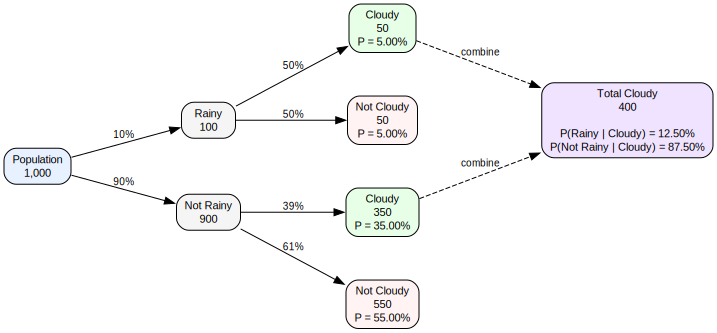

In [ ]:
from probmodels import explain_update

priors = {
    "Rainy": 0.10,
    "Not Rainy": 0.90,
}

likelihoods = {
    "Rainy": 0.50,
    "Not Rainy": 350 / 900,
}

results = explain_update(
    priors,
    likelihoods,
    population_size=1000,
    evidence_name="Cloudy",
    no_evidence_name="Not Cloudy",
    draw_tree=True,
)

results["tree"]

## Step 5: Simulation

Simulate 100,000 days and estimate:

$$P(R \mid C)$$


In [4]:
from probmodels import simulate_bayes_binary

result = simulate_bayes_binary(
    n=100_000,
    p_h=0.10,
    p_e_given_h=0.50,
    p_e_given_not_h=0.3888888889,
    hypothesis_name="Rainy",
    evidence_name="Cloudy",
    seed=42,
)

result["table"]

,Rainy,Not Rainy,Total
Cloudy,4968,34906,39874
Not Cloudy,5075,55051,60126
Total,10043,89957,100000


In [5]:
table = result["table"]

p_rain_given_cloudy = (
    table.loc["Cloudy", "Rainy"]
    / table.loc["Cloudy", "Total"]
)

p_rain_given_cloudy

np.float64(0.12459246626874655)

The simulated estimate should be close to:

$$
P(R \mid C)=0.125
$$

or approximately **12.5%**.


## Key Takeaways

1. This is a Bayes problem because we reverse the conditioning direction.

Given:

$$P(C \mid R)$$

Asked:

$$P(R \mid C)$$

2. Bayes' theorem updates our belief after observing evidence.

3. Although only 10% of days are rainy, a cloudy morning raises the probability of rain to **12.5%**.

4. Most cloudy mornings are still dry.
